# DDPG — Approach 2: critic-driven online fine-tuning (critic from CQL)
Actor warm-started from BC; critic initialised from the trained CQL policy, then the actor is trained iteratively on the critic's feedback. Train + evaluate on Juan's 4 new days.

In [1]:
# ── Setup: shared library (../main_script) + this folder's config ────────────
import os, sys, copy, time
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
sys.path.insert(0, os.getcwd())                                            # for: import config
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), os.pardir)))  # reach ../main_script
from main_script import *
import config as cfg
from config import *
configure(cfg); set_seed(SEED)

# ── BOX switch: pick the gain box to train/evaluate in this run ──────────────
# Edit BOX below and re-run the notebook top-to-bottom. Report labels (exact
# values from the results table in 04_results_discussion.tex):
#   Narrow = original box, same range the Phase-2 CQL critic was trained in
#   Mid    = mid box (report Table: [-6.0,-0.100,-0.60])
#   Wide   = wide box (report Table: [-15.0,-1.5625,-0.525])
BOX = 'Wide'  # 'Narrow' | 'Mid' | 'Wide'
ALGO = "DDPG"
APPROACH = '2'
BOX_GAINS = {
    'Narrow': (np.array([-3.5,  -0.060,  -0.35  ], dtype=np.float32), np.array([-0.05, -0.0001, 0.10], dtype=np.float32)),
    'Mid':    (np.array([-6.0,  -0.100,  -0.60  ], dtype=np.float32), np.array([-0.05, -0.0001, 0.10], dtype=np.float32)),
    'Wide':   (np.array([-15.0, -1.5625, -0.525 ], dtype=np.float32), np.array([-0.05, -0.0001, 0.10], dtype=np.float32)),
}
cfg.GAIN_LOW, cfg.GAIN_HIGH = BOX_GAINS[BOX]
UNDERSHOOT_WEIGHT = 0.15   # checkpoint selection: MAE + w*overshoot + w*undershoot

# canonical name for this (algo, approach, box) — matches main/policies/Best_*BoxPolicy.pt
CANON_TAG = f'Best_{ALGO}_{APPROACH}_{BOX}BoxPolicy'

TWIN = False
EPISODES = 600; UPDATES_PER_CYCLE = 2   # Approach-2: more critic-driven iterations
agent  = DDPG(warm_start=True)
buffer = ReplayBuffer()

# ── Datasets + episode sampler (Juan's new days) ──
train_datasets   = [load_dataset(f) for f in JUAN_FILES]
VAL_FILE         = JUAN_FILES[-1]
episode_datasets = [load_dataset(f) for f in JUAN_FILES if f != VAL_FILE]
train_eval_days  = [d for d in train_datasets if d["name"] != VAL_FILE]
val_eval_days    = [d for d in train_datasets if d["name"] == VAL_FILE]
def get_episode_data(datasets, ep_steps=SHORT_EP_STEPS):
    w = np.array([2.0 if "Cloudy" in d["name"] else 1.0 for d in datasets]); w = w / w.sum()
    idx = int(np.random.choice(len(datasets), p=w)); full = datasets[idx]
    ms = max(0, full["N"] - ep_steps - 1); start = np.random.randint(0, ms + 1) if ms > 0 else 0
    return window(full, start, ep_steps)
print(f"[{ALGO}] agent ready | fine-tune on {len(episode_datasets)} Juan days; VAL={VAL_FILE}")
print(f"[{ALGO}] BOX={BOX} gain box: LOW={list(cfg.GAIN_LOW)} HIGH={list(cfg.GAIN_HIGH)}")


[warm-start] BC trunk loaded from bc_cirl_setpoint_anti_windup_best.pt
[warm-start] head re-centred to START_GAIN Kp=-0.5 Ki=-0.00167


[DDPG] agent ready | fine-tune on 3 Juan days; VAL=19_06_2026__Sunny_Closed_Loop.xlsx
[DDPG] BOX=Wide gain box: LOW=[np.float32(-15.0), np.float32(-1.5625), np.float32(-0.525)] HIGH=[np.float32(-0.05), np.float32(-1e-04), np.float32(0.1)]


In [2]:
# ── Initialise the critic FROM the trained CQL policy ────────────────────────
# "Critic from CQL": load the CQL actor, roll it out on Juan's data to build an
# offline buffer, then fit THIS agent's critic to evaluate that policy (TD policy
# evaluation). The online agent therefore STARTS with the CQL Q-function as its
# first critic — used by both approaches below.
CQL_CKPT           = 'cql_cirl_actor_anti_windup_best.pt'
CQL_PRETRAIN_STEPS = 8000
CQL_PRETRAIN_NOISE = 0.03

def load_cql_actor(ckpt=CQL_CKPT):
    a = Actor().to(DEVICE)
    a.load_state_dict(torch.load(os.path.join(SAVE_DIR, ckpt), map_location=DEVICE, weights_only=True))
    a.eval(); print(f"[cql] policy loaded from {ckpt}")
    return a

def fill_buffer_from_actor(actor_net, datasets, buf, noise_std=CQL_PRETRAIN_NOISE):
    actor_net.eval()
    with torch.no_grad():
        for ds in datasets:
            env = SolarFieldEnv(ds); obs = env.reset(); done = False
            while not done:
                s = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
                a = actor_net(s).cpu().numpy()[0]
                a = np.clip(a + np.random.randn(3).astype(np.float32) * noise_std, 0.0, 1.0)
                obs2, r, done, info = env.step(a); buf.add(obs, a, r, obs2, done); obs = obs2
    return len(buf)

def pretrain_critic_from_cql(agent, cql_actor, datasets, n_updates=CQL_PRETRAIN_STEPS, batch=BATCH_SIZE):
    pre = ReplayBuffer(); n = fill_buffer_from_actor(cql_actor, datasets, pre)
    print(f"[cql-critic] {n} transitions from CQL rollouts; fitting critic for {n_updates} steps...")
    cql_actor.eval(); lc = torch.tensor(0.0)
    for it in range(1, n_updates + 1):
        s, a, r, s2, d = pre.sample(batch)
        with torch.no_grad():
            a2 = cql_actor(s2)                              # evaluate the CQL policy
            if TWIN:
                q1t, q2t = agent.critic_target(s2, a2); qt = r + agent.gamma * (1 - d) * torch.min(q1t, q2t)
            else:
                qt = r + agent.gamma * (1 - d) * agent.critic_target(s2, a2)
        if TWIN:
            q1, q2 = agent.critic(s, a); lc = F.mse_loss(q1, qt) + F.mse_loss(q2, qt)
        else:
            q = agent.critic(s, a); lc = F.mse_loss(q, qt)
        agent.opt_c.zero_grad(); lc.backward(); agent.opt_c.step()
        for tp, p in zip(agent.critic_target.parameters(), agent.critic.parameters()):
            tp.data.mul_(1 - agent.tau); tp.data.add_(agent.tau * p.data)
    print(f"[cql-critic] done; critic initialised as the CQL Q-function (final TD loss {float(lc):.4f}).")

cql_actor = load_cql_actor()
print("CQL critic-pretrain utilities ready.")


[cql] policy loaded from cql_cirl_actor_anti_windup_best.pt
CQL critic-pretrain utilities ready.


In [3]:
# ══════════ APPROACH 2: critic-driven online fine-tuning ══════════
# Actor = BC warm-start; critic INITIALISED FROM CQL, then the actor is
# trained iteratively purely on the critic's feedback (deterministic PG).
TAG = CANON_TAG
SAVE_PATH = os.path.join(SAVE_DIR, f'{TAG}.pt')
pretrain_critic_from_cql(agent, cql_actor, episode_datasets)   # first critic = CQL Q-function
agent.bc_weight = 0.0            # pure critic-driven (no BC anchor pull)

# ── undershoot-aware metrics (tuned): undershoot = worst dip below T_ref AFTER
#    the first crossing (so the initial morning climb is not counted) ──────────
def undershoot_metric(T, tref):
    above = np.nonzero(T >= tref)[0]
    return float(np.max(tref - T[above[0]:])) if len(above) else float(np.max(tref - T))

def eval_actor_und(actor, days, win=EVAL_WIN):
    """Actor rollout -> (mean MAE, mean reward, mean overshoot, worst undershoot)."""
    maes=[]; rews=[]; ovrs=[]; unds=[]; actor.eval()
    for dv in days:
        wd = window(dv, 0, min(win, dv['N'])); env = SolarFieldEnv(wd, dataset_tref(dv['name']))
        obs = env.reset(); done=False; T=[]; rsum=0.0; n=0
        with torch.no_grad():
            while not done:
                s = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
                obs, r, done, info = env.step(actor(s).cpu().numpy()[0]); T.append(info['Tout']); rsum+=r; n+=1
        tr = dataset_tref(dv['name']); T = np.array(T)
        maes.append(mae_rmse(T, tr)[0]); rews.append(rsum/max(n,1))
        ovrs.append(peak_overshoot(T, tr)); unds.append(undershoot_metric(T, tr))
    return float(np.mean(maes)), float(np.mean(rews)), float(np.mean(ovrs)), float(np.max(unds))

def full_day_obj(actor):
    """FULL-DAY checkpoint gate (tuned): deployment objective over ALL 4 Juan days
    = mean MAE + w*worst overshoot + w*worst undershoot. A checkpoint only becomes
    'best' if this improves -- a good validation window can no longer hide a bad
    day (critic-driven runs can oscillate between good and diverged policies)."""
    ms=[]; os_=[]; us=[]; actor.eval()
    for dd in train_datasets:
        env = SolarFieldEnv(dd); obs = env.reset(); done=False; T=[]
        with torch.no_grad():
            while not done:
                s = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
                obs, r, done, info = env.step(actor(s).cpu().numpy()[0]); T.append(info['Tout'])
        tr = dataset_tref(dd['name']); T = np.array(T)
        ms.append(mae_rmse(T, tr)[0]); os_.append(peak_overshoot(T, tr)); us.append(undershoot_metric(T, tr))
    return (float(np.mean(ms)) + OVERSHOOT_WEIGHT * float(np.max(os_))
            + UNDERSHOOT_WEIGHT * float(np.max(us))), float(np.mean(ms))

noise = OUNoise(sigma=0.15, sigma_min=0.01, decay=0.999)
history = {'ep': [], 'train_reward': [], 'val_reward': [], 'train_mae': [], 'val_mae': [],
           'val_overshoot': [], 'Kp': [], 'Ki': [], 'Kw': []}
global_step = 0; best_val_obj = float('inf'); best_fobj = float('inf'); best_exploit_rew = -1e9; stall = 0
EARLY_STOP_PCT, EARLY_STOP_PATIENCE = 0.0001, 100
torch.save(agent.actor.state_dict(), SAVE_PATH)
print(f"Approach 2 [{TAG}] — critic-driven online fine-tune on Juan days (max {EPISODES} ep)\n")

_t0 = time.time()
for ep in range(1, EPISODES + 1):
    data = get_episode_data(episode_datasets, SHORT_EP_STEPS); env = SolarFieldEnv(data)
    obs = env.reset(); done = False; gsum = np.zeros(3); steps = 0
    while not done:
        a = agent.act(obs, noise=noise)
        obs2, r, done, info = env.step(a); buffer.add(obs, a, r, obs2, done)
        gsum += denormalize_gains(a); global_step += 1
        if global_step >= WARMUP_STEPS and global_step % UPDATE_EVERY == 0:
            for _ in range(UPDATES_PER_CYCLE): agent.update(buffer, BATCH_SIZE)
        obs = obs2; steps += 1; noise.step()
    mg = gsum / max(steps, 1)

    tm, tr_, to = eval_actor(agent.actor, train_eval_days)
    vm, vr, vo, vu = eval_actor_und(agent.actor, val_eval_days)
    history['ep'].append(ep); history['train_reward'].append(tr_); history['val_reward'].append(vr)
    history['train_mae'].append(tm); history['val_mae'].append(vm); history['val_overshoot'].append(vo)
    history['Kp'].append(mg[0]); history['Ki'].append(mg[1]); history['Kw'].append(mg[2])

    # checkpoint selection (tuned): cheap val-window screen, then FULL-DAY gate --
    # a checkpoint is saved only if the deployment objective itself improves
    tag = ''; vobj = vm + OVERSHOOT_WEIGHT * vo + UNDERSHOOT_WEIGHT * vu
    if vobj < best_val_obj * 1.02 or vobj < best_val_obj + 0.01:
        best_val_obj = min(best_val_obj, vobj)
        fobj, fmae = full_day_obj(agent.actor)
        if fobj < best_fobj:
            best_fobj = fobj; torch.save(agent.actor.state_dict(), SAVE_PATH)
            tag = f'  <- saved best (full-day MAE {fmae:.3f})'

    stop_now = False
    if vr > best_exploit_rew + abs(best_exploit_rew) * EARLY_STOP_PCT:
        best_exploit_rew = vr; stall = 0
    else:
        stall += 1; stop_now = stall >= EARLY_STOP_PATIENCE

    if ep % EVAL_EVERY == 0 or ep == 1 or stop_now:
        print(f"Ep {ep:3d} | mean gains Kp={mg[0]:+.3f} Ki={mg[1]:+.5f} Kw={mg[2]:+.4f} "
              f"| train_rew={tr_:.4f} val_rew={vr:.4f} | val MAE={vm:.3f} ovr={vo:.3f} und={vu:.3f}{tag}")
    if stop_now:
        print(f"EARLY STOP at ep {ep}: val reward plateaued."); break

print(f"\nApproach 2 done in {(time.time()-_t0)/60:.1f} min. Best -> {os.path.basename(SAVE_PATH)}")


[cql-critic] 55185 transitions from CQL rollouts; fitting critic for 8000 steps...


[cql-critic] done; critic initialised as the CQL Q-function (final TD loss 3.7295).
Approach 2 [Best_DDPG_2_WideBoxPolicy] — critic-driven online fine-tune on Juan days (max 600 ep)



Ep   1 | mean gains Kp=-1.216 Ki=-0.07282 Kw=+0.0001 | train_rew=1.4136 val_rew=2.3252 | val MAE=0.799 ovr=4.950 und=0.276  <- saved best (full-day MAE 1.216)


Ep  10 | mean gains Kp=-14.872 Ki=-1.55017 Kw=-0.5202 | train_rew=8.3000 val_rew=8.8002 | val MAE=0.050 ovr=2.399 und=0.652  <- saved best (full-day MAE 0.030)


Ep  20 | mean gains Kp=-14.899 Ki=-1.55185 Kw=-0.5198 | train_rew=8.3000 val_rew=8.8002 | val MAE=0.050 ovr=2.399 und=0.652  <- saved best (full-day MAE 0.030)


...

Ep  70 | mean gains Kp=-14.907 Ki=-1.55179 Kw=-0.5197 | train_rew=8.3000 val_rew=8.8002 | val MAE=0.050 ovr=2.399 und=0.652  <- saved best (full-day MAE 0.030)


Ep  80 | mean gains Kp=-14.897 Ki=-1.55226 Kw=-0.5204 | train_rew=8.3000 val_rew=8.8002 | val MAE=0.050 ovr=2.399 und=0.652


Ep  90 | mean gains Kp=-14.900 Ki=-1.55280 Kw=-0.5209 | train_rew=8.3000 val_rew=8.8002 | val MAE=0.050 ovr=2.399 und=0.652


Ep 100 | mean gains Kp=-14.884 Ki=-1.55172 Kw=-0.5193 | train_rew=8.3000 val_rew=8.8002 | val MAE=0.050 ovr=2.399 und=0.652


Ep 107 | mean gains Kp=-14.910 Ki=-1.54902 Kw=-0.5205 | train_rew=8.3000 val_rew=8.8002 | val MAE=0.050 ovr=2.399 und=0.652
EARLY STOP at ep 107: val reward plateaued.

Approach 2 done in 22.6 min. Best -> Best_DDPG_2_WideBoxPolicy.pt


In [4]:
# ── Final evaluation on Juan's days (deterministic rollout of the best actor) ──
def rollout_full(actor, data, tref=None):
    env = SolarFieldEnv(data, tref); obs = env.reset(); done = False
    T=[]; Q=[]; G=[]; actor.eval()
    with torch.no_grad():
        while not done:
            s = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
            a = actor(s).cpu().numpy()[0]; G.append(denormalize_gains(a))
            obs, r, done, info = env.step(a); T.append(info['Tout']); Q.append(info['q'])
    return np.array(T), np.array(Q), np.array(G)

best_actor = Actor().to(DEVICE)
best_actor.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE, weights_only=True)); best_actor.eval()

print(f"{'Juan day':40s} | {TAG} MAE   RMSE   ovr    und | Expert MAE   ovr    und")
print('-' * 108)
rows = []
for ds in train_datasets:
    tr = dataset_tref(ds['name'])
    T, Q, G   = rollout_full(best_actor, ds)
    Te, Qe    = rollout_expert(ds)
    m, rm     = mae_rmse(T, tr);  ov  = peak_overshoot(T, tr);  un  = undershoot_metric(T, tr)
    me, rme   = mae_rmse(Te, tr); ove = peak_overshoot(Te, tr); une = undershoot_metric(Te, tr)
    rows.append((ds['name'], m, rm, ov, un, me, ove, une))
    print(f"{ds['name']:40s} | {m:6.3f} {rm:6.3f} {ov:6.3f} {un:6.3f} | {me:6.3f} {ove:6.3f} {une:6.3f}")
print('-' * 108)
print("MEAN over Juan days:  %s MAE=%.3f RMSE=%.3f ovr=%.3f und=%.3f  |  Expert MAE=%.3f ovr=%.3f und=%.3f"
      % (TAG, np.mean([r[1] for r in rows]), np.mean([r[2] for r in rows]), np.mean([r[3] for r in rows]),
         np.mean([r[4] for r in rows]),
         np.mean([r[5] for r in rows]), np.mean([r[6] for r in rows]), np.mean([r[7] for r in rows])))


Juan day                                 | Best_DDPG_2_WideBoxPolicy MAE   RMSE   ovr    und | Expert MAE   ovr    und
------------------------------------------------------------------------------------------------------------


16_06_2026__Sunny_Closed_Loop.xlsx       |  0.022  0.110  2.644  0.651 |  1.286  5.425  5.972


17_06_2026__Sunny_Closed_Loop.xlsx       |  0.053  0.548  0.718  0.476 |  1.482  5.117  7.945


18_06_2026__Sunny_Closed_Loop.xlsx       |  0.037  0.190  2.836  0.569 |  1.796  8.219  6.434


19_06_2026__Sunny_Closed_Loop.xlsx       |  0.007  0.104  2.399  0.652 |  0.331  4.935  1.351
------------------------------------------------------------------------------------------------------------
MEAN over Juan days:  Best_DDPG_2_WideBoxPolicy MAE=0.030 RMSE=0.238 ovr=2.149 und=0.587  |  Expert MAE=1.224 ovr=5.924 und=5.425


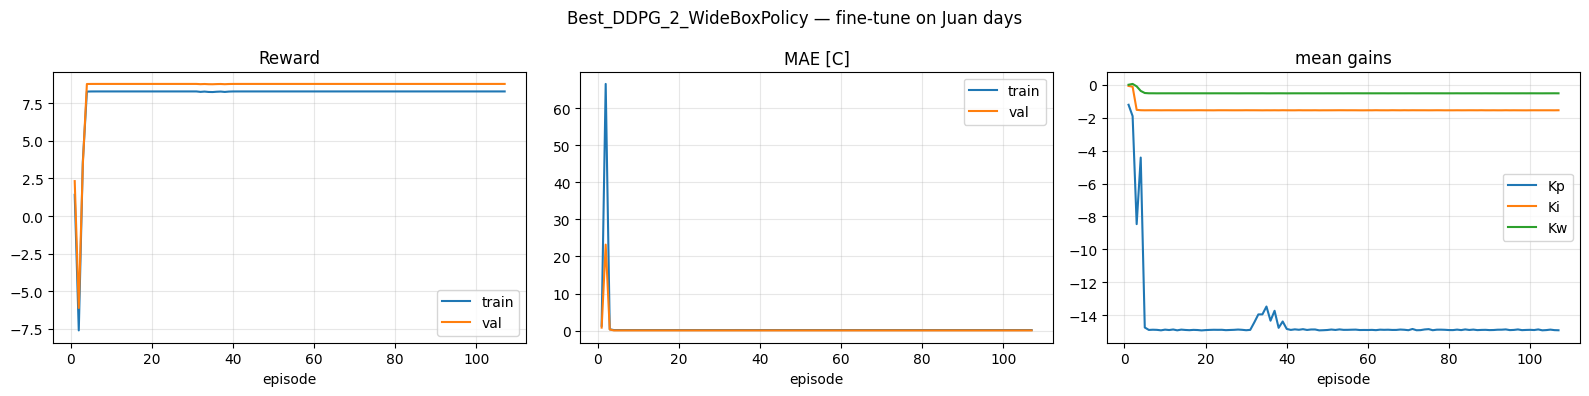

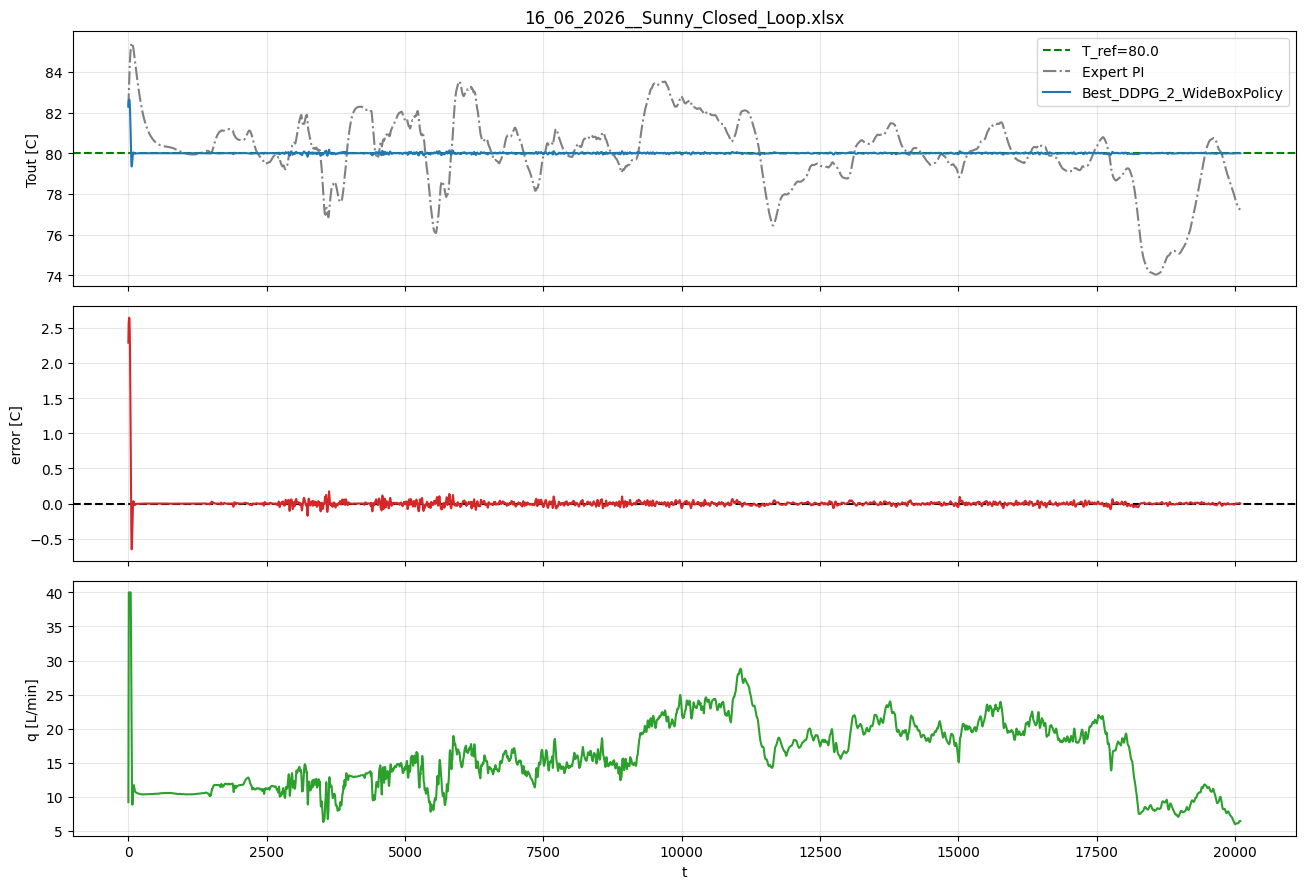

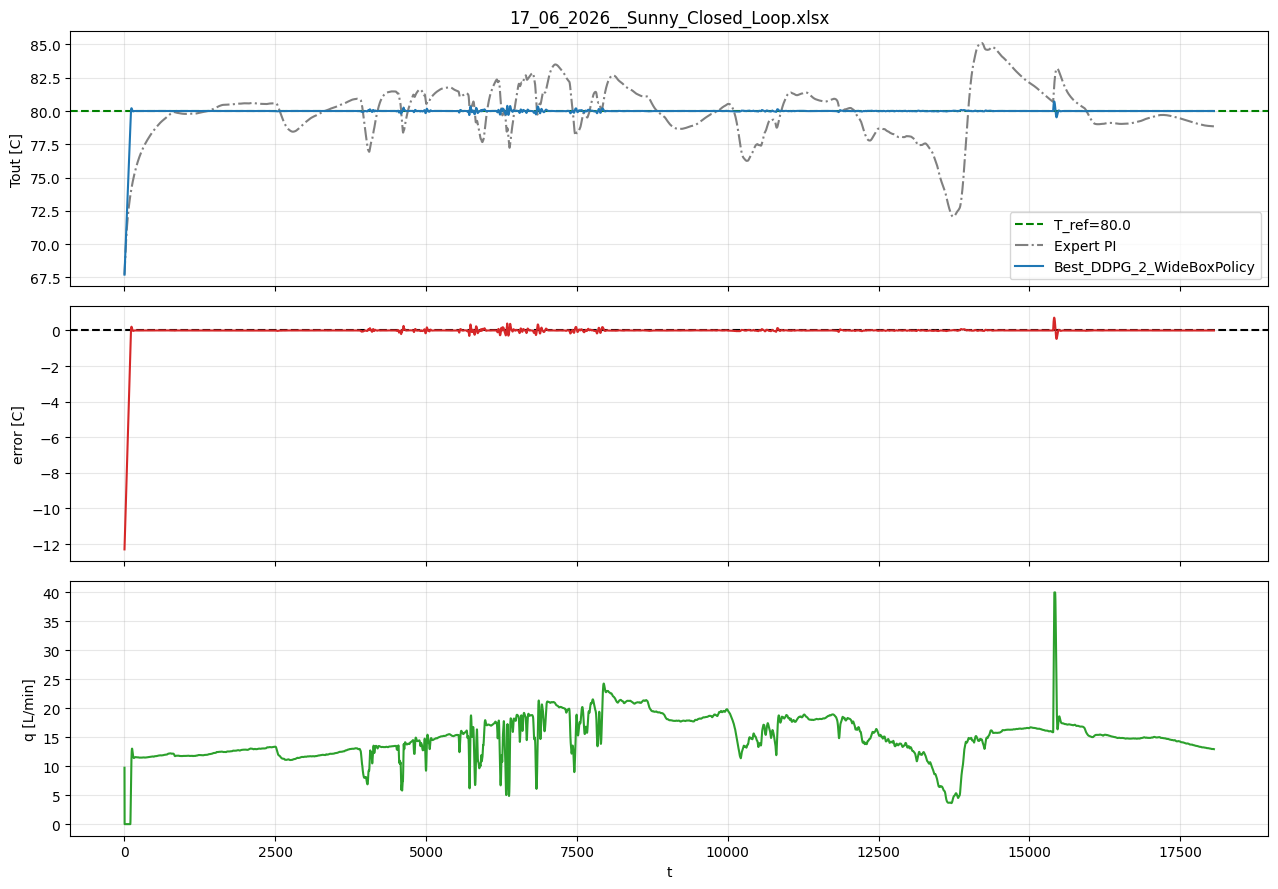

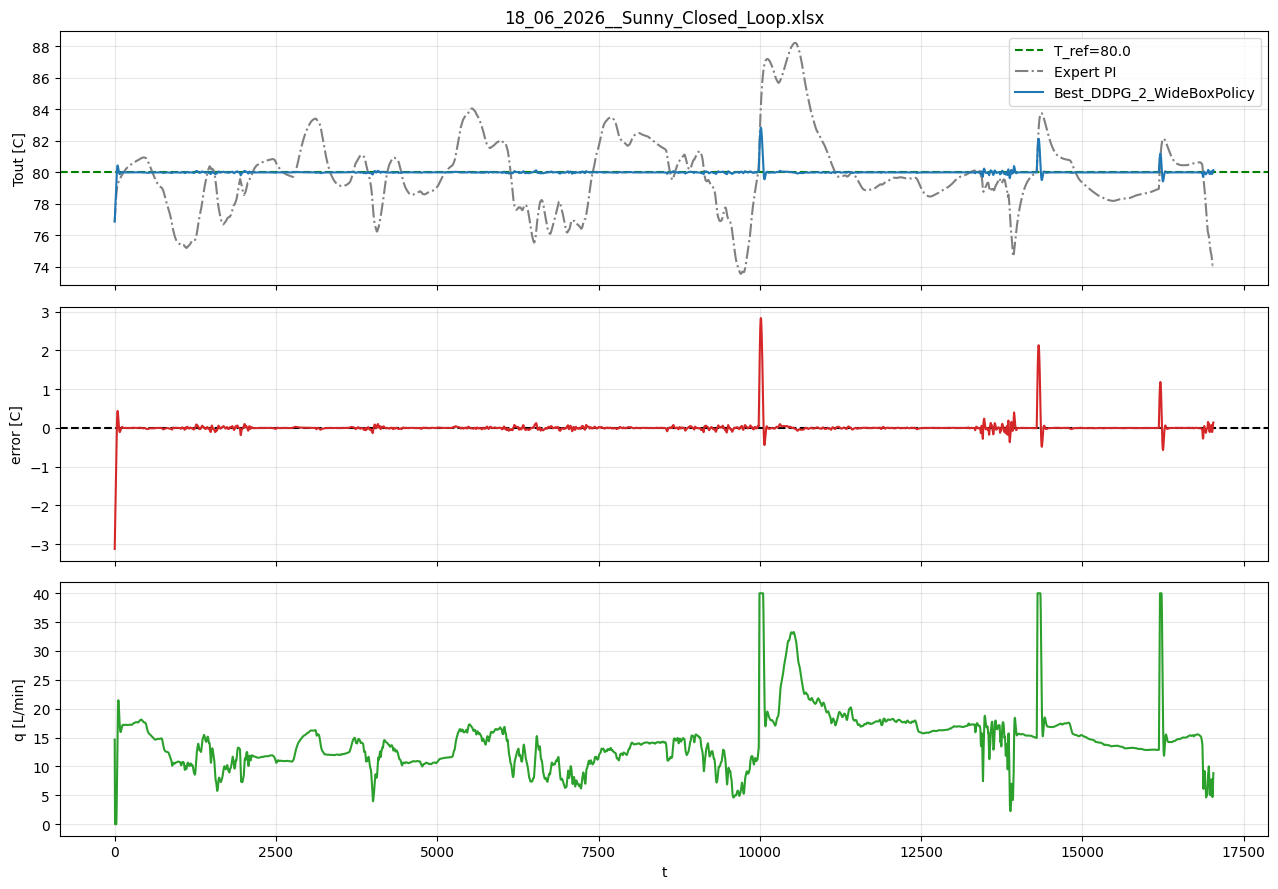

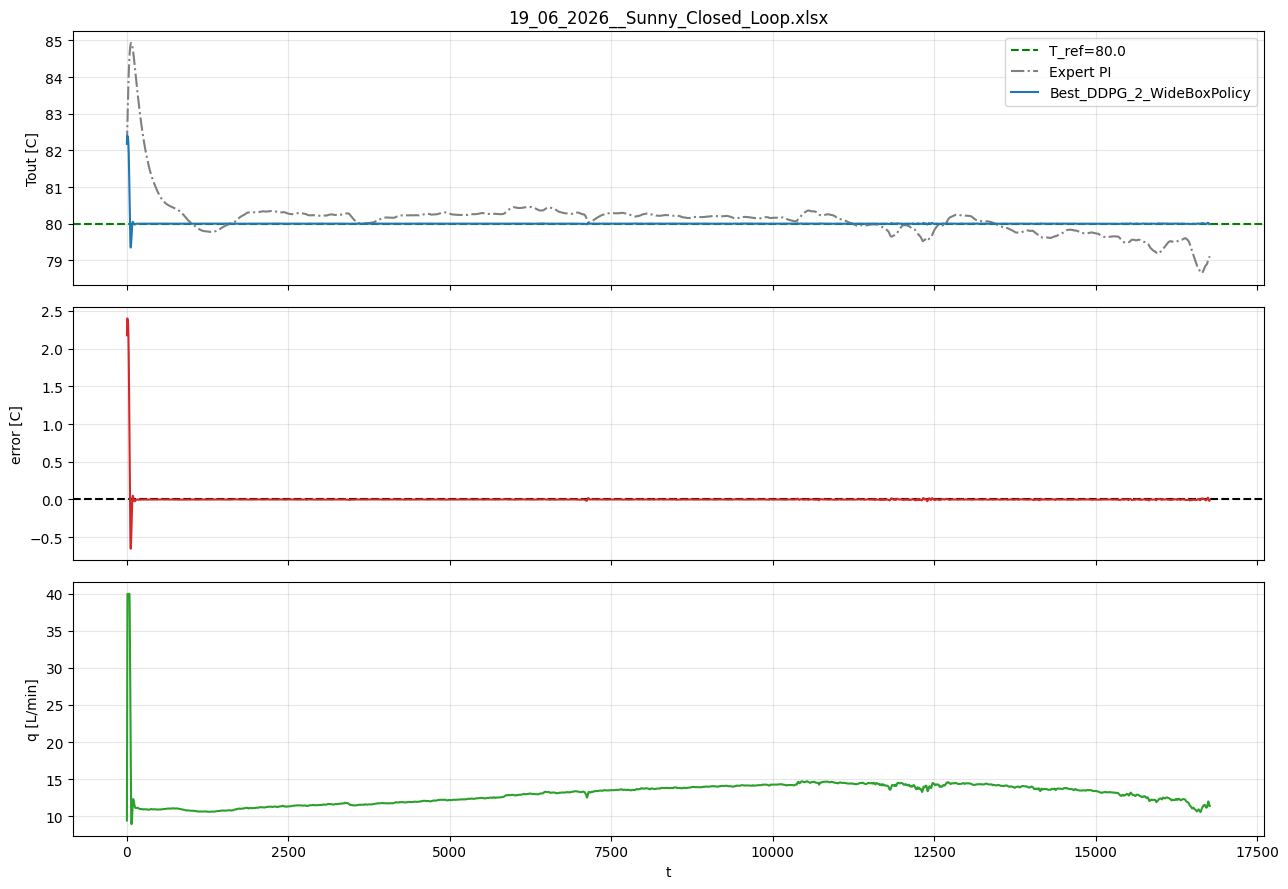

In [5]:
# ── Fine-tune curves + per-Juan-day tracking ─────────────────────────────────
pd.DataFrame(history).to_csv(os.path.join(CHART_DIR, f'{TAG}_history.csv'), index=False)

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].plot(history['ep'], history['train_reward'], label='train'); ax[0].plot(history['ep'], history['val_reward'], label='val')
ax[0].set_title('Reward'); ax[0].set_xlabel('episode'); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(history['ep'], history['train_mae'], label='train'); ax[1].plot(history['ep'], history['val_mae'], label='val')
ax[1].set_title('MAE [C]'); ax[1].set_xlabel('episode'); ax[1].legend(); ax[1].grid(alpha=.3)
ax[2].plot(history['ep'], history['Kp'], label='Kp'); ax[2].plot(history['ep'], history['Ki'], label='Ki'); ax[2].plot(history['ep'], history['Kw'], label='Kw')
ax[2].set_title('mean gains'); ax[2].set_xlabel('episode'); ax[2].legend(); ax[2].grid(alpha=.3)
fig.suptitle(f'{TAG} — fine-tune on Juan days'); fig.tight_layout()
fig.savefig(os.path.join(CHART_DIR, f'{TAG}_curves.png'), dpi=150); plt.show()

for ds in train_datasets:
    tr = dataset_tref(ds['name']); T, Q, G = rollout_full(best_actor, ds); Te, Qe = rollout_expert(ds)
    t = np.arange(len(T))
    fig, ax = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
    ax[0].axhline(tr, ls='--', c='g', label=f'T_ref={tr}'); ax[0].plot(t, Te[:len(T)], c='gray', ls='-.', label='Expert PI')
    ax[0].plot(t, T, c='C0', label=TAG); ax[0].set_ylabel('Tout [C]'); ax[0].set_title(ds['name']); ax[0].legend(); ax[0].grid(alpha=.3)
    ax[1].axhline(0, c='k', ls='--'); ax[1].plot(t, T - tr, c='C3'); ax[1].set_ylabel('error [C]'); ax[1].grid(alpha=.3)
    ax[2].plot(t, Q, c='C2'); ax[2].set_ylabel('q [L/min]'); ax[2].set_xlabel('t'); ax[2].grid(alpha=.3)
    fig.tight_layout()
    lbl = "_".join(ds['name'].split("_")[:3])
    fig.savefig(os.path.join(CHART_DIR, f'{TAG}_day_{lbl}.png'), dpi=140); plt.show()
